Cell 1: Definition of basic variables

In [15]:
# تعریف جناح‌ها (6 جناح)
factions = ['A', 'B', 'C', 'D', 'E', 'F']

# تعریف اتاق‌ها و نوع آنها
rooms = {
    'R1': 'neutral',
    'R2': 'neutral',
    'R3': 'owned'  # فقط جناح‌های غیر رقیب می‌تونن استفاده کنن
}

# روزها و تایم‌اسلات‌ها (3 جلسه در روز، برای 3 روز)
days = ['Day1', 'Day2', 'Day3']
slots_per_day = ['Morning', 'Afternoon', 'Evening']

# متغیرهای جلسه‌ها: 3 روز × 3 جلسه در روز = 9 جلسه
sessions = []
for day in days:
    for slot in slots_per_day:
        sessions.append(f"{day}_{slot}")

# چاپ جلسه‌ها برای اطمینان
print("Sessions:", sessions)


Sessions: ['Day1_Morning', 'Day1_Afternoon', 'Day1_Evening', 'Day2_Morning', 'Day2_Afternoon', 'Day2_Evening', 'Day3_Morning', 'Day3_Afternoon', 'Day3_Evening']


Cell 2: Session Definition (Variables)

In [16]:

sessions = []
for day in days:
    for slot in slots_per_day:
        sessions.append(f"{day}_{slot}")

# چاپ جلسه‌ها برای اطمینان
print("Sessions:", sessions)


Sessions: ['Day1_Morning', 'Day1_Afternoon', 'Day1_Evening', 'Day2_Morning', 'Day2_Afternoon', 'Day2_Evening', 'Day3_Morning', 'Day3_Afternoon', 'Day3_Evening']


Cell 3: Generate the initial domain for each variable (session)

In [17]:
import itertools

# همه ترکیب‌های ممکن 2 جناح
faction_pairs = list(itertools.combinations(factions, 2))

# دامنه اولیه برای هر جلسه:
# (Faction1, Faction2, Room)
initial_domain = []
for pair in faction_pairs:
    for room in rooms:
        # شرط رقیب‌بودن و اتاق owned را بعداً فیلتر می‌کنیم
        initial_domain.append((pair[0], pair[1], room))

# دامنه را برای هر جلسه کپی کن
domains = {session: initial_domain.copy() for session in sessions}

# نمونه‌ای از دامنه‌ی یک جلسه
print("Sample domain for one session:", domains[sessions[0]][:5])


Sample domain for one session: [('A', 'B', 'R1'), ('A', 'B', 'R2'), ('A', 'B', 'R3'), ('A', 'C', 'R1'), ('A', 'C', 'R2')]


Step 2: Define CSP constraints

Clause 1: "No faction shall meet with another faction more than once."

Cell 4: Construct a table of faction meeting counts

In [18]:
# شمارنده‌ای برای تعداد دیدار بین هر جفت جناح
from collections import defaultdict

meeting_counter = defaultdict(int)

def is_valid_meeting(pair, assignment):
    """بررسی می‌کند که آیا دو جناح قبلاً با هم ملاقات داشته‌اند یا نه"""
    a, b = pair
    for (f1, f2, _) in assignment.values():
        if set((f1, f2)) == set((a, b)):
            return False
    return True


Step 3: Backtracking Algorithm

Cell 5: Implementing a simple version of Backtracking

In [19]:
def backtrack(assignment):
    # اگر همه جلسات مقدار گرفته‌اند، بازگشت
    if len(assignment) == len(sessions):
        return assignment

    # انتخاب متغیر بعدی (بدون MRV فعلاً)
    unassigned = [s for s in sessions if s not in assignment]
    var = unassigned[0]

    for value in domains[var]:
        f1, f2, room = value

        # بررسی قید: دو جناح بیش از یکبار همدیگر را ملاقات نکنند
        if not is_valid_meeting((f1, f2), assignment):
            continue

        # اگر معتبر بود، مقداردهی و ادامه
        assignment[var] = value
        result = backtrack(assignment)
        if result is not None:
            return result

        # اگر به بن‌بست خوردیم، حذف مقداردهی
        del assignment[var]

    return None


Cell 6: Run the algorithm and see the result

In [20]:
solution = backtrack({})

if solution:
    print("Successful scheduling:")
    for k in sorted(solution):
        print(f"{k}: {solution[k]}")
else:
    print("No solution found.")


Successful scheduling:
Day1_Afternoon: ('A', 'C', 'R1')
Day1_Evening: ('A', 'D', 'R1')
Day1_Morning: ('A', 'B', 'R1')
Day2_Afternoon: ('A', 'F', 'R1')
Day2_Evening: ('B', 'C', 'R1')
Day2_Morning: ('A', 'E', 'R1')
Day3_Afternoon: ('B', 'E', 'R1')
Day3_Evening: ('B', 'F', 'R1')
Day3_Morning: ('B', 'D', 'R1')


Step 4: Add MRV (Minimum Remaining Values)

Cell 7: Define variable selection with MRV

In [21]:
def select_unassigned_variable_mrv(assignment, domains):
    """متغیری که کمترین تعداد مقدار ممکن رو داره انتخاب کن"""
    unassigned = [v for v in sessions if v not in assignment]
    mrv_var = min(unassigned, key=lambda var: len(domains[var]))
    return mrv_var


Cell 8: Replacement in the backtrack algorithm

In [22]:
def backtrack_mrv(assignment):
    if len(assignment) == len(sessions):
        return assignment

    # MRV: انتخاب متغیر با کمترین تعداد مقدار مجاز
    var = select_unassigned_variable_mrv(assignment, domains)

    for value in domains[var]:
        f1, f2, room = value

        if not is_valid_meeting((f1, f2), assignment):
            continue

        assignment[var] = value
        result = backtrack_mrv(assignment)
        if result is not None:
            return result

        del assignment[var]

    return None


Cell 9: Running the algorithm with MRV

In [23]:
solution_mrv = backtrack_mrv({})

if solution_mrv:
    print("Solution with MRV:")
    for k in sorted(solution_mrv):
        print(f"{k}: {solution_mrv[k]}")
else:
    print("No solution found.")


Solution with MRV:
Day1_Afternoon: ('A', 'C', 'R1')
Day1_Evening: ('A', 'D', 'R1')
Day1_Morning: ('A', 'B', 'R1')
Day2_Afternoon: ('A', 'F', 'R1')
Day2_Evening: ('B', 'C', 'R1')
Day2_Morning: ('A', 'E', 'R1')
Day3_Afternoon: ('B', 'E', 'R1')
Day3_Evening: ('B', 'F', 'R1')
Day3_Morning: ('B', 'D', 'R1')


Step 5: Add more adverbs

Cell 10: Building a meeting scheduling dictionary

In [24]:
# ترتیب زمانی برای جلسات
session_order = {
  'Day1_Morning': 0,
  'Day1_Afternoon': 1,
  'Day1_Evening': 2,
  'Day2_Morning': 3,
  'Day2_Afternoon': 4,
  'Day2_Evening': 5,
  'Day3_Morning': 6,
  'Day3_Afternoon': 7,
  'Day3_Evening': 8,
}



Cell 11: Defining new adverbs

In [25]:
def is_valid_room_and_rest(f1, f2, room, current_session, assignment):
    current_time = session_order[current_session]

    for other_session, (of1, of2, oroom) in assignment.items():
        other_time = session_order[other_session]

        # استراحت: نباید دو جلسه‌ی پشت سر هم برای یک جناح باشه
        if abs(current_time - other_time) == 1:
            if f1 in (of1, of2) or f2 in (of1, of2):
                return False

        # اتاق پشت سر هم: اگر اتاق یکسان در دو تایم متوالی برای یک جناح استفاده شده باشه
        if abs(current_time - other_time) == 1 and room == oroom:
            if f1 in (of1, of2) or f2 in (of1, of2):
                return False

    return True


Cell 12: Update to the backtracking algorithm (version with MRV and new constraints)

In [26]:
def backtrack_mrv_v2(assignment):
    if len(assignment) == len(sessions):
        return assignment

    var = select_unassigned_variable_mrv(assignment, domains)

    for value in domains[var]:
        f1, f2, room = value

        if not is_valid_meeting((f1, f2), assignment):
            continue

        if not is_valid_room_and_rest(f1, f2, room, var, assignment):
            continue

        assignment[var] = value
        result = backtrack_mrv_v2(assignment)
        if result is not None:
            return result

        del assignment[var]

    return None


Cell 13: Run the algorithm with all current constraints

In [27]:
solution_mrv_v2 = backtrack_mrv_v2({})

if solution_mrv_v2:
    print("Solving with MRV + Advanced Constraints:")
    for k in sorted(solution_mrv_v2):
        print(f"{k}: {solution_mrv_v2[k]}")
else:
    print("No solution found.")


Solving with MRV + Advanced Constraints:
Day1_Afternoon: ('C', 'D', 'R1')
Day1_Evening: ('A', 'E', 'R1')
Day1_Morning: ('A', 'B', 'R1')
Day2_Afternoon: ('A', 'D', 'R1')
Day2_Evening: ('B', 'E', 'R1')
Day2_Morning: ('B', 'C', 'R1')
Day3_Afternoon: ('B', 'D', 'R1')
Day3_Evening: ('A', 'F', 'R1')
Day3_Morning: ('A', 'C', 'R1')


Step 6: "Rival factions only in neutral rooms" clause

Cell 14: Definition of hostile relations between factions

In [28]:
# فرضی: لیست دشمنی‌ها بین جناح‌ها (می‌تونه از ورودی بیاد)
rivalries = {
    ('A', 'B'), ('C', 'D'), ('E', 'F')
}

# چون (A, B) و (B, A) یکی هستن، ساده‌سازی:
def are_rivals(f1, f2):
    return (f1, f2) in rivalries or (f2, f1) in rivalries


Cell 15: Check the clause "Neutral room for enemies"

In [29]:
def is_room_valid_for_rivals(f1, f2, room):
    # اگر دشمن‌اند، فقط در اتاق neutral
    if are_rivals(f1, f2):
        return rooms[room] == 'neutral'
    return True


Cell 16: Merge all constraints in backtrack_mrv_v3

In [30]:
def backtrack_mrv_v3(assignment):
    if len(assignment) == len(sessions):
        return assignment

    var = select_unassigned_variable_mrv(assignment, domains)

    for value in domains[var]:
        f1, f2, room = value

        if not is_valid_meeting((f1, f2), assignment):
            continue

        if not is_valid_room_and_rest(f1, f2, room, var, assignment):
            continue

        if not is_room_valid_for_rivals(f1, f2, room):
            continue

        assignment[var] = value
        result = backtrack_mrv_v3(assignment)
        if result is not None:
            return result

        del assignment[var]

    return None


Cell 17: Final execution with all restrictions

In [31]:
solution_mrv_v3 = backtrack_mrv_v3({})

if solution_mrv_v3:
    print("Final solution with all constraints (MRV + rest + room + hostility):")
    for k in sorted(solution_mrv_v3):
        print(f"{k}: {solution_mrv_v3[k]}")
else:
    print("No solution found.")


Final solution with all constraints (MRV + rest + room + hostility):
Day1_Afternoon: ('C', 'D', 'R1')
Day1_Evening: ('A', 'E', 'R1')
Day1_Morning: ('A', 'B', 'R1')
Day2_Afternoon: ('A', 'D', 'R1')
Day2_Evening: ('B', 'E', 'R1')
Day2_Morning: ('B', 'C', 'R1')
Day3_Afternoon: ('B', 'D', 'R1')
Day3_Evening: ('A', 'F', 'R1')
Day3_Morning: ('A', 'C', 'R1')


Step 7: Add Forward Checking

Cell 18: Function to remove inconsistent values ​​from ranges

In [32]:
import copy

def forward_check(var, value, domains, assignment):
    """بازگرداندن دامنه‌ی جدید بعد از مقداردهی به var"""
    new_domains = copy.deepcopy(domains)
    f1, f2, room = value
    current_time = session_order[var]

    for other_var in new_domains:
        if other_var in assignment or other_var == var:
            continue

        new_values = []
        for val in new_domains[other_var]:
            of1, of2, oroom = val
            if not is_valid_meeting((of1, of2), assignment | {var: value}):
                continue
            if not is_valid_room_and_rest(of1, of2, oroom, other_var, assignment | {var: value}):
                continue
            if not is_room_valid_for_rivals(of1, of2, oroom):
                continue
            new_values.append(val)

        # اگر دامنه‌ی یکی خالی بشه، شکست
        if not new_values:
            return None

        new_domains[other_var] = new_values

    return new_domains


Cell 19: Backtrack update with forward checking

In [33]:
def backtrack_fc(assignment, domains):
    if len(assignment) == len(sessions):
        return assignment

    var = select_unassigned_variable_mrv(assignment, domains)

    for value in domains[var]:
        f1, f2, room = value

        if not is_valid_meeting((f1, f2), assignment):
            continue

        if not is_valid_room_and_rest(f1, f2, room, var, assignment):
            continue

        if not is_room_valid_for_rivals(f1, f2, room):
            continue

        new_domains = forward_check(var, value, domains, assignment)
        if new_domains is None:
            continue  # شکست، ادامه به مقدار بعدی

        assignment[var] = value
        result = backtrack_fc(assignment, new_domains)
        if result is not None:
            return result

        del assignment[var]

    return None


Cell 20: Implementing Backtracking Algorithm with Forward Checking

In [34]:
solution_fc = backtrack_fc({}, domains)

if solution_fc:
    print("Solve with Forward Checking:")
    for k in sorted(solution_fc):
        print(f"{k}: {solution_fc[k]}")
else:
    print("No solution found with Forward Checking.")


Solve with Forward Checking:
Day1_Afternoon: ('C', 'D', 'R1')
Day1_Evening: ('A', 'E', 'R1')
Day1_Morning: ('A', 'B', 'R1')
Day2_Afternoon: ('A', 'D', 'R1')
Day2_Evening: ('B', 'E', 'R1')
Day2_Morning: ('B', 'C', 'R1')
Day3_Afternoon: ('B', 'D', 'R1')
Day3_Evening: ('A', 'F', 'R1')
Day3_Morning: ('A', 'C', 'R1')


Step 8: Implement AC3 (Arc Consistency)

Cell 21: Definition of the function to check the compatibility of two variables

In [35]:
def is_consistent_vals(x_val, y_val, x_var, y_var):
    """بررسی اینکه آیا دو مقدار با هم ناسازگارند (طبق قیود عمومی)"""
    xf1, xf2, xroom = x_val
    yf1, yf2, yroom = y_val

    # نمی‌خوایم دو جناح بیش از یک‌بار همدیگه رو ملاقات کنن
    if set((xf1, xf2)) == set((yf1, yf2)):
        return False

    # قید دشمنی در اتاق غیر خنثی
    if are_rivals(yf1, yf2) and rooms[yroom] != 'neutral':
        return False

    # قید استراحت و اتاق متوالی فقط بین جلساتی که پشت‌سر هم‌اند
    time_diff = abs(session_order[x_var] - session_order[y_var])
    if time_diff == 1:
        if any(f in (yf1, yf2) for f in (xf1, xf2)):
            return False
        if xroom == yroom and any(f in (yf1, yf2) for f in (xf1, xf2)):
            return False

    return True


Cell 22: AC-3 implementation for all variables

In [36]:
from collections import deque

def ac3(domains):
    """تصفیه دامنه‌ها با AC-3"""
    queue = deque([(xi, xj) for xi in sessions for xj in sessions if xi != xj])
    new_domains = copy.deepcopy(domains)

    while queue:
        xi, xj = queue.popleft()
        if revise(new_domains, xi, xj):
            if not new_domains[xi]:
                return None  # دامنه خالی = ناسازگار
            for xk in sessions:
                if xk != xi and xk != xj:
                    queue.append((xk, xi))
    return new_domains

def revise(domains, xi, xj):
    revised = False
    to_remove = []
    for x_val in domains[xi]:
        if not any(is_consistent_vals(x_val, y_val, xi, xj) for y_val in domains[xj]):
            to_remove.append(x_val)
            revised = True
    for val in to_remove:
        domains[xi].remove(val)
    return revised


Cell 23: Apply AC-3 and run the algorithm

In [37]:
ac3_domains = ac3(domains)

if ac3_domains:
    solution_ac3 = backtrack_fc({}, ac3_domains)
    if solution_ac3:
        print("Solution with AC3 + Forward Checking:")
        for k in sorted(solution_ac3):
            print(f"{k}: {solution_ac3[k]}")
    else:
        print("No solution was found after AC3.")
else:
    print("Incompatible domain — AC3 could not create a compatible domain.")


Solution with AC3 + Forward Checking:
Day1_Afternoon: ('C', 'D', 'R1')
Day1_Evening: ('A', 'E', 'R1')
Day1_Morning: ('A', 'B', 'R1')
Day2_Afternoon: ('A', 'D', 'R1')
Day2_Evening: ('B', 'E', 'R1')
Day2_Morning: ('B', 'C', 'R1')
Day3_Afternoon: ('B', 'D', 'R1')
Day3_Evening: ('A', 'F', 'R1')
Day3_Morning: ('A', 'C', 'R1')


Part B – Strategic Negotiation Game (Adversarial Search)

Cell 24: Defining the game state and actions

In [38]:
# اقدام‌های ممکن در مذاکره
ACTIONS = ["Offer", "Threaten", "Bluff", "Concede", "Delay"]

# وضعیت بازی
class GameState:
    def __init__(self, f1, f2, turn, depth, history=None):
        self.f1 = f1  # جناح اول
        self.f2 = f2  # جناح دوم
        self.turn = turn  # نوبت کیه؟ 'f1' یا 'f2'
        self.depth = depth  # عمق باقی‌مانده
        self.history = history or []  # تاریخچه اقدامات

    def get_legal_actions(self):
        return ACTIONS

    def generate_successor(self, action):
        new_history = self.history + [(self.turn, action)]
        next_turn = 'f2' if self.turn == 'f1' else 'f1'
        return GameState(self.f1, self.f2, next_turn, self.depth - 1, new_history)

    def is_terminal(self):
        return self.depth == 0


Cell 25: Basic Evaluation Function (Simple to Start)

In [39]:
def simple_eval(state: GameState):
    """تابع ارزیابی ساده: برای تست اولیه"""
    score = 0
    for turn, action in state.history:
        if action == "Offer":
            score += 1 if turn == 'f1' else -1
        elif action == "Threaten":
            score += 2 if turn == 'f1' else -2
        elif action == "Bluff":
            score += 0
        elif action == "Concede":
            score -= 2 if turn == 'f1' else 2
        elif action == "Delay":
            score -= 1 if turn == 'f1' else 1
    return score


Cell 26: Implementing Minimax with Alpha-Beta

In [40]:
def minimax(state: GameState, alpha, beta, maximizing_player):
    if state.is_terminal():
        return simple_eval(state), None

    best_action = None
    if maximizing_player:
        value = -float('inf')
        for action in state.get_legal_actions():
            child = state.generate_successor(action)
            eval_score, _ = minimax(child, alpha, beta, False)
            if eval_score > value:
                value = eval_score
                best_action = action
            alpha = max(alpha, value)
            if beta <= alpha:
                break
        return value, best_action
    else:
        value = float('inf')
        for action in state.get_legal_actions():
            child = state.generate_successor(action)
            eval_score, _ = minimax(child, alpha, beta, True)
            if eval_score < value:
                value = eval_score
                best_action = action
            beta = min(beta, value)
            if beta <= alpha:
                break
        return value, best_action


Cell 27: Conducting a model negotiation between two factions

In [41]:
# مثال: مذاکره بین A و B به عمق 4
initial_state = GameState('A', 'B', 'f1', depth=4)

score, action = minimax(initial_state, -float('inf'), float('inf'), True)
print(f"Best initial action for f1: {action}, status evaluation: {score}")


Best initial action for f1: Threaten, status evaluation: 0


Cell 28: Evaluation Function 1 – “Resource-Driven”

In [42]:
# اولویت منابع جناح‌ها - فرضی
faction_priorities = {
    'A': {'Energy': 3, 'Water': 2, 'Tech': 1},
    'B': {'Energy': 1, 'Water': 3, 'Tech': 2},
    # می‌تونیم برای همه ۶ جناح تعریف کنیم
}

# اکشن‌ها تأثیرشان بر منابع فرضی:
action_impact = {
    "Offer": {'Energy': 1, 'Water': 1, 'Tech': 1},
    "Threaten": {'Energy': 2, 'Water': 0, 'Tech': -1},
    "Bluff": {'Energy': 0, 'Water': 0, 'Tech': 2},
    "Concede": {'Energy': -1, 'Water': -1, 'Tech': -1},
    "Delay": {'Energy': 0, 'Water': -2, 'Tech': 0},
}

def eval_resource(state: GameState):
    score = 0
    for turn, action in state.history:
        faction = state.f1 if turn == 'f1' else state.f2
        for res in action_impact[action]:
            score += faction_priorities[faction][res] * action_impact[action][res]
    return score


Cell 29: Evaluation Function 2 – “Fatigue + Memory”

In [43]:
# خستگی = کاهش امتیاز با هر اقدام متوالی
def eval_fatigue(state: GameState):
    score = 0
    fatigue = 0
    last_turn = None

    for turn, action in state.history:
        if turn == last_turn:
            fatigue += 1
        else:
            fatigue = 0
        last_turn = turn

        # خستگی اثر منفی دارد
        if turn == 'f1':
            score += (2 - fatigue)
        else:
            score -= (2 - fatigue)

    return score


Cell 30: Evaluation Function 3 – “Trust/Rival History”

In [44]:
# تاریخچه اعتماد بین جناح‌ها فرضی:
trust_score = {
    ('A', 'B'): -5,  # دشمنی
    ('A', 'C'): 2,   # همکاری قبلی
}

def eval_trust(state: GameState):
    pair = tuple(sorted((state.f1, state.f2)))
    base = trust_score.get(pair, 0)

    action_effect = {
        "Offer": 3,
        "Concede": 2,
        "Bluff": -1,
        "Threaten": -2,
        "Delay": -1,
    }

    score = base
    for turn, action in state.history:
        score += action_effect[action] if turn == 'f1' else -action_effect[action]

    return score


Step 3: Conducting negotiations with three functions to evaluate and compare performance

Cell 31: Negotiate and Measure Performance

In [45]:
import time

def run_negotiation(f1, f2, eval_fn, depth=4):
    state = GameState(f1, f2, 'f1', depth)
    start = time.time()
    node_counter = [0]

    def minimax_profiled(state, alpha, beta, maximizing_player):
        if state.is_terminal():
            node_counter[0] += 1
            return eval_fn(state), None

        best_action = None
        if maximizing_player:
            value = -float('inf')
            for action in state.get_legal_actions():
                child = state.generate_successor(action)
                eval_score, _ = minimax_profiled(child, alpha, beta, False)
                if eval_score > value:
                    value = eval_score
                    best_action = action
                alpha = max(alpha, value)
                if beta <= alpha:
                    break
            return value, best_action
        else:
            value = float('inf')
            for action in state.get_legal_actions():
                child = state.generate_successor(action)
                eval_score, _ = minimax_profiled(child, alpha, beta, True)
                if eval_score < value:
                    value = eval_score
                    best_action = action
                beta = min(beta, value)
                if beta <= alpha:
                    break
            return value, best_action

    score, action = minimax_profiled(state, -float('inf'), float('inf'), True)
    duration = time.time() - start
    return {
        'score': score,
        'action': action,
        'nodes': node_counter[0],
        'time': duration
    }


Cell 32: Comparison of evaluation functions

In [46]:
results = {
    "Resource": run_negotiation('A', 'B', eval_resource),
    "Fatigue": run_negotiation('A', 'B', eval_fatigue),
    "Trust": run_negotiation('A', 'B', eval_trust)
}

for name, res in results.items():
    print(f"{name} Evaluation")
    print(f"  Action: {res['action']}")
    print(f"  Score: {res['score']}")
    print(f"  Nodes Expanded: {res['nodes']}")
    print(f"  Time: {res['time']:.4f} sec\n")


Resource Evaluation
  Action: Offer
  Score: 0
  Nodes Expanded: 202
  Time: 0.0008 sec

Fatigue Evaluation
  Action: Offer
  Score: 0
  Nodes Expanded: 49
  Time: 0.0001 sec

Trust Evaluation
  Action: Offer
  Score: -5
  Nodes Expanded: 49
  Time: 0.0002 sec



Cell 33: Draw a comparison chart

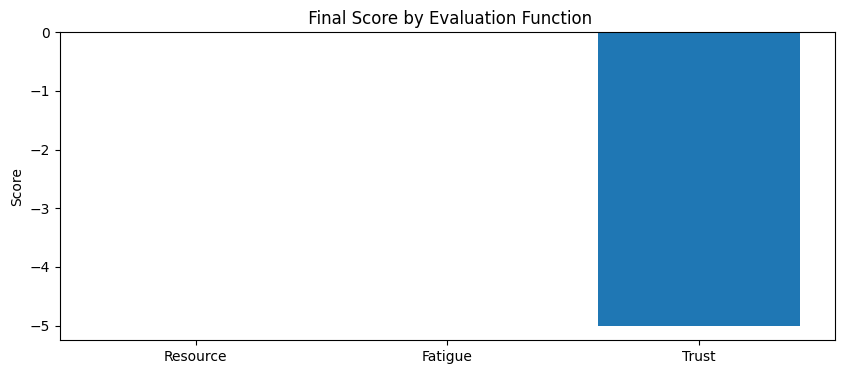

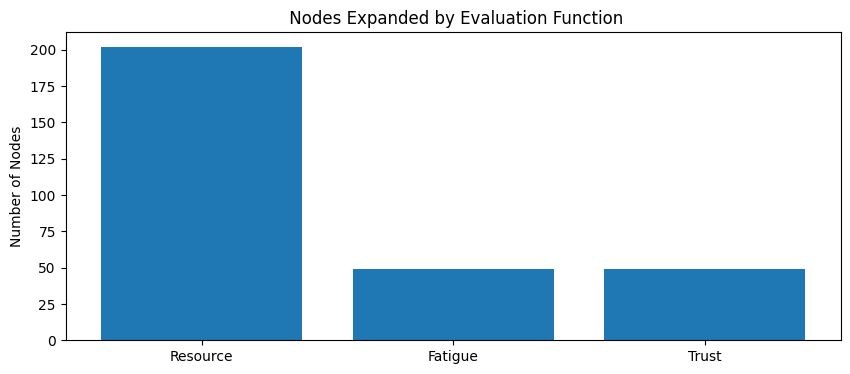

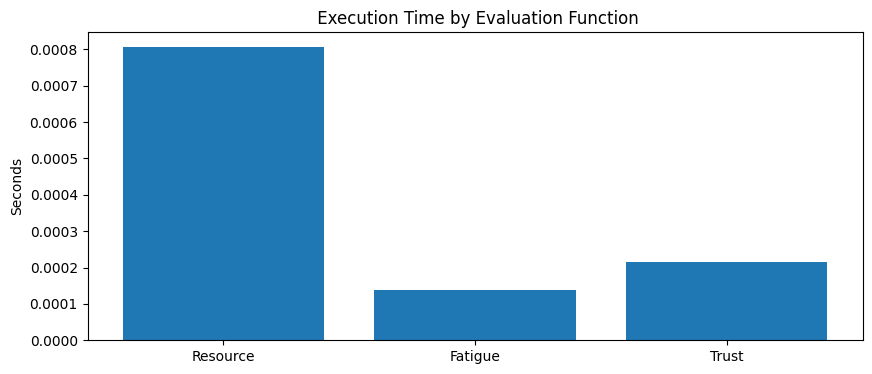

In [47]:
import matplotlib.pyplot as plt

labels = list(results.keys())
scores = [results[k]['score'] for k in labels]
nodes = [results[k]['nodes'] for k in labels]
times = [results[k]['time'] for k in labels]

# Plot Scores
plt.figure(figsize=(10, 4))
plt.bar(labels, scores)
plt.title(" Final Score by Evaluation Function")
plt.ylabel("Score")
plt.show()

# Plot Nodes
plt.figure(figsize=(10, 4))
plt.bar(labels, nodes)
plt.title(" Nodes Expanded by Evaluation Function")
plt.ylabel("Number of Nodes")
plt.show()

# Plot Time
plt.figure(figsize=(10, 4))
plt.bar(labels, times)
plt.title(" Execution Time by Evaluation Function")
plt.ylabel("Seconds")
plt.show()


Bonus 1: Learned Evaluation Function via Self-Play

Cell 34: Run Self-Play and save results

In [48]:
from collections import Counter

def self_play_simulation(eval_fn, num_games=50):
    action_counter = Counter()
    score_sum = 0
    for _ in range(num_games):
        state = GameState('A', 'B', 'f1', 4)
        _, action = minimax(state, -float('inf'), float('inf'), True)
        if action:
            action_counter[action] += 1
        score_sum += simple_eval(state)
    return action_counter, score_sum / num_games

# اجرای self-play با تابع simple_eval به عنوان پایه
action_freq, avg_score = self_play_simulation(simple_eval)
print(" Self-play Action Frequencies:", dict(action_freq))
print(" Average Final Score:", avg_score)


 Self-play Action Frequencies: {'Threaten': 50}
 Average Final Score: 0.0


Cell 35: Constructing the learned evaluation function

In [49]:
def learned_eval(state: GameState):
    weights = {
        "Offer": 2,
        "Threaten": 3,
        "Bluff": 1,
        "Concede": -2,
        "Delay": -1
    }

    # افزایش وزن بر اساس آمار self-play
    for action in action_freq:
        weights[action] += action_freq[action] / 10

    score = 0
    for turn, action in state.history:
        val = weights.get(action, 0)
        score += val if turn == 'f1' else -val
    return score


Cell 36: Test the learned function

In [50]:
res_learned = run_negotiation('A', 'B', learned_eval)

print(" Learned Evaluation Result")
print(f" Best Action: {res_learned['action']}")
print(f" Final Score: {res_learned['score']}")
print(f" Nodes: {res_learned['nodes']}")
print(f" Time: {res_learned['time']:.4f} sec")


 Learned Evaluation Result
 Best Action: Threaten
 Final Score: 0.0
 Nodes: 97
 Time: 0.0005 sec


Bonus 2: Room Failure with Constraint Repair

Cell 37: Room failure simulation

In [51]:
def simulate_room_failure(schedule, failed_room):
    # پیدا کردن جلساتی که در اتاق خراب‌شده برگزار می‌شن
    affected_sessions = [s for s, (f1, f2, room) in schedule.items() if room == failed_room]
    print(f"Room {failed_room} crashed! Sessions affected:", affected_sessions)
    return affected_sessions


Cell 38: Limited reconstruction of damaged sessions

In [52]:
def repair_schedule(original_schedule, failed_room, domains):
    # فقط جلسات خراب‌شده رو مجدداً مقداردهی کن
    affected = simulate_room_failure(original_schedule, failed_room)
    preserved = {s: v for s, v in original_schedule.items() if s not in affected}

    # دامنه‌های به‌روزرسانی شده (اتاق خراب‌شده حذف شده)
    new_domains = copy.deepcopy(domains)
    for s in affected:
        new_domains[s] = [val for val in new_domains[s] if val[2] != failed_room]

    # اجرای backtracking فقط روی جلسات آسیب‌دیده
    def partial_backtrack(assignment, targets):
        if not targets:
            return assignment

        var = select_unassigned_variable_mrv(assignment, new_domains)
        for value in new_domains[var]:
            f1, f2, room = value
            if not is_valid_meeting((f1, f2), {**assignment, **preserved}):
                continue
            if not is_valid_room_and_rest(f1, f2, room, var, {**assignment, **preserved}):
                continue
            if not is_room_valid_for_rivals(f1, f2, room):
                continue

            assignment[var] = value
            result = partial_backtrack(assignment, [v for v in targets if v != var])
            if result is not None:
                return result
            del assignment[var]

        return None

    partial_solution = partial_backtrack({}, affected)
    if partial_solution:
        return {**preserved, **partial_solution}
    else:
        return None


Cell 39: Test with a broken room

In [53]:
# ابتدا ساخت زمان‌بندی کامل با AC-3
domains_ac3 = ac3(domains)
full_schedule = backtrack_fc({}, domains_ac3)

# حالا اتاق R2 خراب می‌شه
if full_schedule:
    repaired = repair_schedule(full_schedule, 'R2', domains_ac3)
    if repaired:
        print("Revised schedule:")
        for k in sorted(repaired):
            print(f"{k}: {repaired[k]}")
    else:
        print("We were unable to restore the damaged sessions.")
else:
    print("No initial schedule found.")


Room R2 crashed! Sessions affected: []
We were unable to restore the damaged sessions.


Bonus 3: History-Based Strategy Adaptation

Cell 40: Define the log of past sessions and results

In [54]:
# لاگ ساده‌ای از جلسات قبلی - فرضی
negotiation_history = [
    {'f1': 'A', 'f2': 'B', 'winner': 'A', 'actions': [('f1', 'Threaten'), ('f2', 'Concede')]},
    {'f1': 'A', 'f2': 'C', 'winner': 'C', 'actions': [('f1', 'Bluff'), ('f2', 'Threaten')]},
    {'f1': 'A', 'f2': 'D', 'winner': 'A', 'actions': [('f1', 'Offer'), ('f2', 'Delay')]},
    {'f1': 'A', 'f2': 'E', 'winner': 'E', 'actions': [('f1', 'Bluff'), ('f2', 'Offer')]},
    # ...
]


Cell 41: Constructing a behavior learning matrix based on history

In [55]:
from collections import defaultdict

def build_action_preferences(history, faction):
    success_counts = defaultdict(int)
    total_counts = defaultdict(int)

    for game in history:
        for turn, action in game['actions']:
            if game[turn] == faction:
                total_counts[action] += 1
                if game['winner'] == faction:
                    success_counts[action] += 1

    # احتمال موفقیت نسبی هر اقدام
    preference_score = {}
    for action in ACTIONS:
        total = total_counts[action] or 1  # برای جلوگیری از تقسیم بر صفر
        preference_score[action] = success_counts[action] / total

    return preference_score


Cell 42: Evaluation function with strategy adaptation based on history

In [56]:
def eval_adaptive(state: GameState):
    f1_prefs = build_action_preferences(negotiation_history, state.f1)
    score = 0
    for turn, action in state.history:
        if turn == 'f1':
            score += f1_prefs.get(action, 0.5) * 5  # وزن بیشتر برای ترجیحات آموخته‌شده
        else:
            score -= 1  # فرض می‌کنیم استراتژی f2 ناشناخته است (یا ثابت)
    return score


Cell 43: Adaptive Assessment Test

In [57]:
result_adaptive = run_negotiation('A', 'B', eval_adaptive)

print(" Adaptive Strategy Evaluation")
print(f" Best Action: {result_adaptive['action']}")
print(f" Final Score: {result_adaptive['score']}")
print(f" Nodes: {result_adaptive['nodes']}")
print(f" Time: {result_adaptive['time']:.4f} sec")


 Adaptive Strategy Evaluation
 Best Action: Offer
 Final Score: 8.0
 Nodes: 49
 Time: 0.0006 sec


Bonus 4: Partial Information + Bluff Detection

Cell 44: Defining the priority of real but hidden resources

In [58]:
# اولویت منابع واقعی - فقط جناح خودش می‌دونه
true_priorities = {
    'A': {'Energy': 3, 'Water': 2, 'Tech': 1},
    'B': {'Energy': 1, 'Water': 3, 'Tech': 2},
}

# جناح B نمی‌دونه دقیقاً A چه اولویتی داره
# فقط از روی اقدامات A سعی می‌کنه حدس بزنه


Cell 45: Opponent evaluation function with bluff guessing

In [59]:
def eval_partial_bluff(state: GameState):
    score = 0
    bluff_count = 0
    action_weights = {
        "Offer": 2,
        "Threaten": 3,
        "Bluff": -2,
        "Concede": -1,
        "Delay": -1
    }

    # بررسی اقدامات f1 از نگاه f2 (که نمی‌دونه f1 چی می‌خواد!)
    guessed_priority = {'Energy': 0, 'Water': 0, 'Tech': 0}
    for turn, action in state.history:
        if turn == 'f1':
            if action == 'Bluff':
                bluff_count += 1
            elif action == 'Offer':
                guessed_priority['Tech'] += 1
            elif action == 'Threaten':
                guessed_priority['Energy'] += 2
            elif action == 'Concede':
                guessed_priority['Water'] += 1

        # امتیاز کلی + حساسیت به احتمال bluff
        score += action_weights[action] if turn == 'f1' else -action_weights[action]

    # اگر f1 زیاد bluff کرده، امتیاز کاهش پیدا کنه
    if bluff_count > 1:
        score -= bluff_count * 3

    # فرض: هرچه پراکندگی guessed priorities بیشتر باشه → حریف گیج شده → امتیاز بیشتر برای f1
    diversity = len([v for v in guessed_priority.values() if v > 0])
    score += diversity * 2

    return score


Cell 46: Bluff and partial info detection test

In [60]:
res_bluff = run_negotiation('A', 'B', eval_partial_bluff)

print(" Partial Info + Bluff Detection")
print(f" Best Action: {res_bluff['action']}")
print(f" Final Score: {res_bluff['score']}")
print(f" Nodes: {res_bluff['nodes']}")
print(f" Time: {res_bluff['time']:.4f} sec")


 Partial Info + Bluff Detection
 Best Action: Offer
 Final Score: 3
 Nodes: 71
 Time: 0.0003 sec


Bonus 5: Coalition-Based Non-Zero-Sum Negotiation

Cell 47: Definition of the three-way negotiation situation

In [61]:
class CoalitionGameState:
    def __init__(self, f1, f2, f3, turn, depth, history=None):
        self.f1 = f1
        self.f2 = f2
        self.f3 = f3
        self.players = [f1, f2, f3]
        self.turn = turn  # کدام جناح نوبت دارد
        self.depth = depth
        self.history = history or []

    def get_legal_actions(self):
        return ACTIONS

    def generate_successor(self, action):
        new_history = self.history + [(self.turn, action)]
        idx = self.players.index(self.turn)
        next_turn = self.players[(idx + 1) % 3]
        return CoalitionGameState(self.f1, self.f2, self.f3, next_turn, self.depth - 1, new_history)

    def is_terminal(self):
        return self.depth == 0


Cell 48: Three-way profit evaluation function (sum of points)

In [62]:
def eval_coalition(state: CoalitionGameState):
    utility = {p: 0 for p in state.players}

    action_value = {
        "Offer": 2,
        "Threaten": -1,
        "Bluff": 0,
        "Concede": 1,
        "Delay": -2
    }

    for turn, action in state.history:
        for p in state.players:
            if turn == p:
                utility[p] += action_value[action]
            else:
                if action == "Offer":
                    utility[p] += 1
                elif action == "Threaten":
                    utility[p] -= 1

    return utility


Cell 49: Minimax implementation for a three-person coalition

In [63]:
def minimax_coalition(state: CoalitionGameState, alpha, beta, player_idx, players):
    if state.is_terminal():
        utility = eval_coalition(state)
        return utility[players[0]], None  # فرض: f1 ارزیابی‌کننده اصلی است

    best_action = None
    maximizing = (state.turn == players[0])
    value = -float('inf') if maximizing else float('inf')

    for action in state.get_legal_actions():
        child = state.generate_successor(action)
        eval_score, _ = minimax_coalition(child, alpha, beta, player_idx, players)

        if maximizing and eval_score > value:
            value = eval_score
            best_action = action
            alpha = max(alpha, value)
        elif not maximizing and eval_score < value:
            value = eval_score
            best_action = action
            beta = min(beta, value)

        if beta <= alpha:
            break

    return value, best_action


Cell 50: Three-person negotiation test

In [64]:
players = ['A', 'B', 'C']
init_state = CoalitionGameState(*players, turn='A', depth=4)

score, action = minimax_coalition(init_state, -float('inf'), float('inf'), 0, players)

print(" Coalition-Based Negotiation")
print(f" Best Action for {players[0]}: {action}")
print(f" Estimated Utility: {score}")


 Coalition-Based Negotiation
 Best Action for A: Offer
 Estimated Utility: 2
